# Employee Attrition Prediction using Machine Learning

## Internship Project – Week 2

### Objective
The objective of this project is to build a machine learning model that predicts whether an employee is likely to leave the company based on employee-related factors such as job satisfaction, monthly income, work-life balance, years at the company, and job role.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [2]:
##loading dataset
df = pd.read_csv("HR_Attrition.csv")

## Data Loading and Exploration

In [3]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [4]:
df.shape

(1470, 35)

### Observation

The dataset contains 1470 employee records and 35 columns representing employee information and the target variable.

In [5]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

### Observation

The target variable is **Attrition**, which indicates whether an employee left the company.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [8]:
##target column
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [9]:
attrition_rate = (df["Attrition"] == "Yes").mean() * 100

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


### Observation

The employee attrition rate is approximately 16%, meaning that most employees stay with the company. This indicates that the dataset is imbalanced because the number of employees who stayed is much higher than the number who left.

In [10]:
#numeric columns
numeric_columns = df.select_dtypes(include=["int64", "float64"])

print("Number of Numeric Columns:", numeric_columns.shape[1])

Number of Numeric Columns: 26


In [11]:
#categorical columns
categorical_columns = df.select_dtypes(include=["object"])

print("Number of Categorical Columns:", categorical_columns.shape[1])

Number of Categorical Columns: 9


## Data cleaning and Preprocessing

In [12]:
# missing values
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Observation

There are no missing values in the dataset. Therefore, no missing value treatment is required.

In [13]:
## drop unnecessary columns
df.drop(
    columns=["EmployeeNumber", "Over18", "StandardHours"],
    inplace=True
)

In [14]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

### Observation

EmployeeNumber, Over18, and StandardHours were removed because they do not contribute to predicting employee attrition.

In [15]:
## convert yes to 1 and no to 0
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

In [16]:
df["Attrition"].head()

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

### Observation

The target variable was converted into numerical format where:
- 1 represents an employee who left the company.
- 0 represents an employee who stayed.

In [17]:
## Seperate features and target

X = df.drop("Attrition", axis=1)

y = df["Attrition"]

In [18]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns

print(numeric_features)

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


In [19]:
categorical_features = X.select_dtypes(include=["object"]).columns

print(categorical_features)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [20]:
## One hot encoding- convert categorical to numeric before model training
X = pd.get_dummies(X, drop_first=True)

In [21]:
X.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,1,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,1,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,1,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


In [22]:
X = X.astype({col: 'int' for col in X.select_dtypes('bool').columns})
X.head()


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,1,2,94,3,2,4,...,0,0,0,0,0,1,0,0,1,1
1,49,279,8,1,1,3,61,2,2,2,...,0,0,0,0,1,0,0,1,0,0
2,37,1373,2,2,1,4,92,2,1,3,...,1,0,0,0,0,0,0,0,1,1
3,33,1392,3,4,1,4,56,3,1,3,...,0,0,0,0,1,0,0,1,0,1
4,27,591,2,1,1,1,40,3,1,2,...,1,0,0,0,0,0,0,1,0,0


In [23]:
## Scaling
scaler = StandardScaler()

In [24]:
X[numeric_features] = scaler.fit_transform(X[numeric_features])

In [25]:
X.head()


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,0.0,-0.660531,1.383138,0.379672,-0.057788,1.153254,...,0,0,0,0,0,1,0,0,1,1
1,1.322365,-1.297775,-0.147150,-1.868426,0.0,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,...,0,0,0,0,1,0,0,1,0,0
2,0.008343,1.414363,-0.887515,-0.891688,0.0,1.169781,1.284725,-1.026167,-0.961486,0.246200,...,1,0,0,0,0,0,0,0,1,1
3,-0.429664,1.461466,-0.764121,1.061787,0.0,1.169781,-0.486709,0.379672,-0.961486,0.246200,...,0,0,0,0,1,0,0,1,0,1
4,-1.086676,-0.524295,-0.887515,-1.868426,0.0,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,...,1,0,0,0,0,0,0,1,0,0


In [26]:
print(X.shape)

(1470, 45)


## Data Preprocessing Summary

- Checked for missing values (none found).
- Removed unnecessary columns: EmployeeNumber, Over18, and StandardHours.
- Converted the target variable (Attrition) from Yes/No to 1/0.
- Applied One-Hot Encoding to all categorical variables.
- Standardized all numerical features using StandardScaler.

## Exploratory Data Analysis (EDA)

## Attrition Rate by Department

In [27]:

department_attrition = df.groupby("Department")["Attrition"].mean() * 100

department_attrition


Department
Human Resources           19.047619
Research & Development    13.839750
Sales                     20.627803
Name: Attrition, dtype: float64

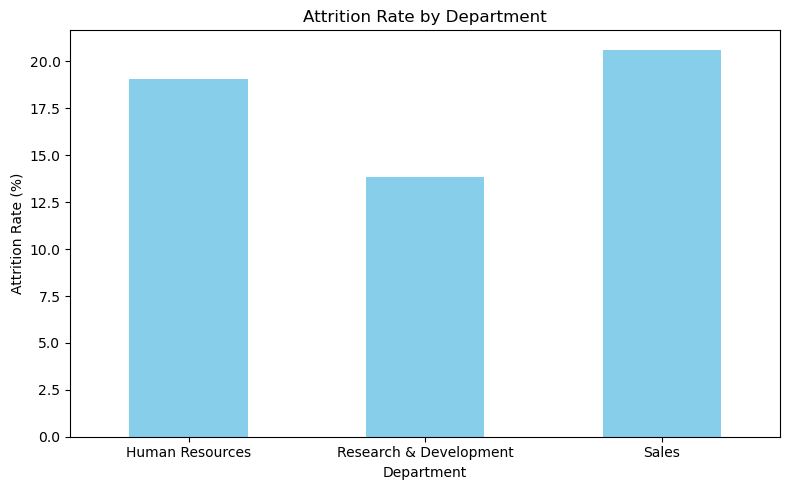

In [28]:
department_attrition.plot(kind="bar", figsize=(8,5), color="skyblue")

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("charts/chart1_department_attrition.png")

plt.show()

### Observation

- The Sales department has the highest attrition rate at approximately 21%.
- Human Resources also experiences a relatively high attrition rate of about 19%.
- Research & Development has the lowest attrition rate at around 14%.
- This indicates that employees in the Sales department are more likely to leave the company compared to other departments.

## Attrition Rate by Job Role

In [29]:
jobrole_attrition = df.groupby("JobRole")["Attrition"].mean() * 100

jobrole_attrition = jobrole_attrition.sort_values(ascending=False)

jobrole_attrition

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64

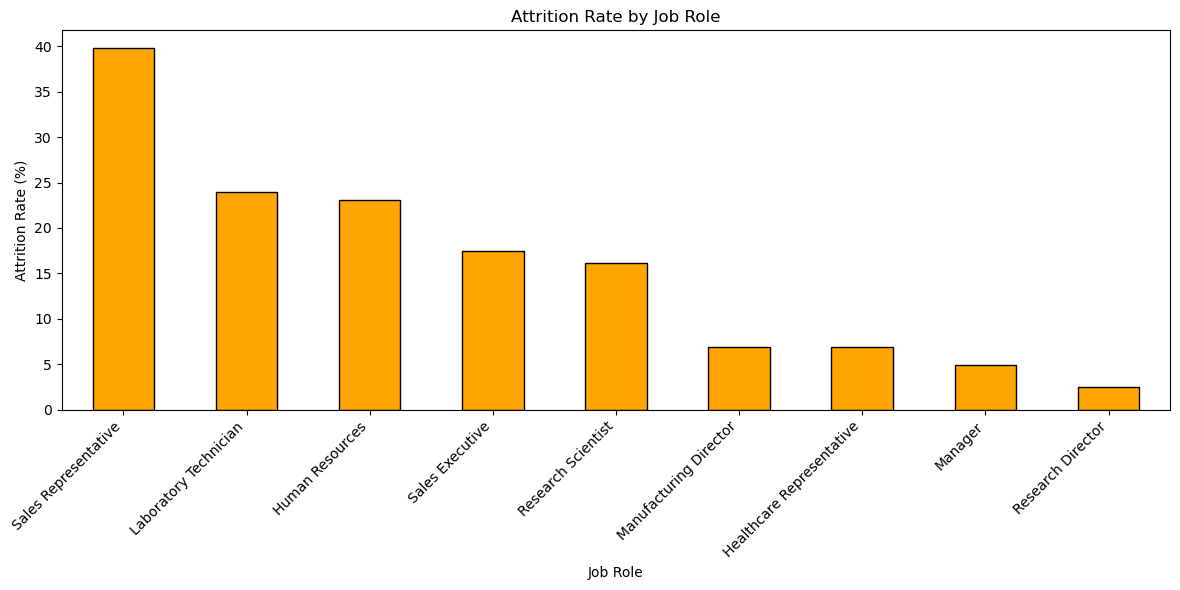

In [30]:
plt.figure(figsize=(12,6))

jobrole_attrition.plot(
    kind="bar",
    color="orange",
    edgecolor="black"
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig("charts/chart2_jobrole_attrition.png")

plt.show()

### Observation

- Sales Representatives have the highest attrition rate at nearly 40%.
- Laboratory Technicians and Human Resources employees also show relatively high attrition rates.
- Research Directors and Managers have the lowest attrition rates among all job roles.
- HR should prioritize retention strategies for Sales Representatives and Laboratory Technicians, as these roles experience the greatest employee turnover.

## Attrition vs Monthly Income

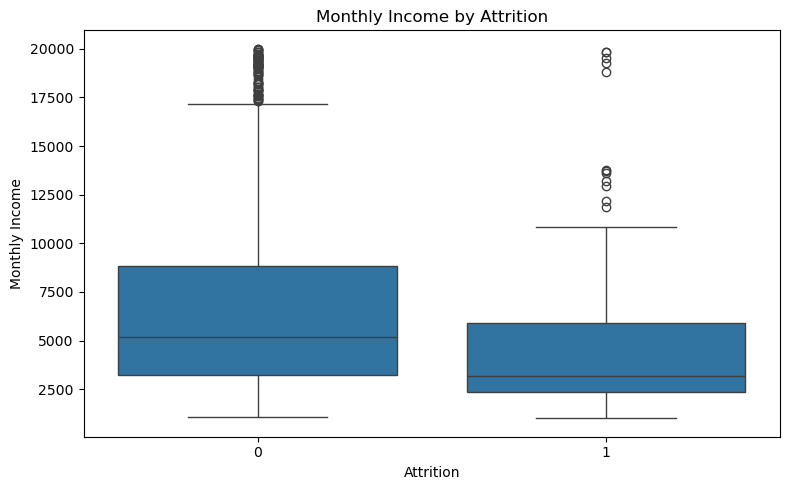

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)

plt.title("Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.tight_layout()

plt.savefig("charts/chart3_monthly_income.png")

plt.show()

### Observation

- Employees who left the company generally have lower monthly incomes than employees who stayed.
- The median monthly income of employees who left is noticeably lower than that of employees who remained.
- Although lower income appears to be associated with higher attrition, several high-income employees also left the company.
- This suggests that salary influences attrition but is not the only factor affecting an employee's decision to leave.

## Attrition vs Work-Life Balance

In [32]:
worklife_attrition = df.groupby("WorkLifeBalance")["Attrition"].mean() * 100

worklife_attrition

WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64

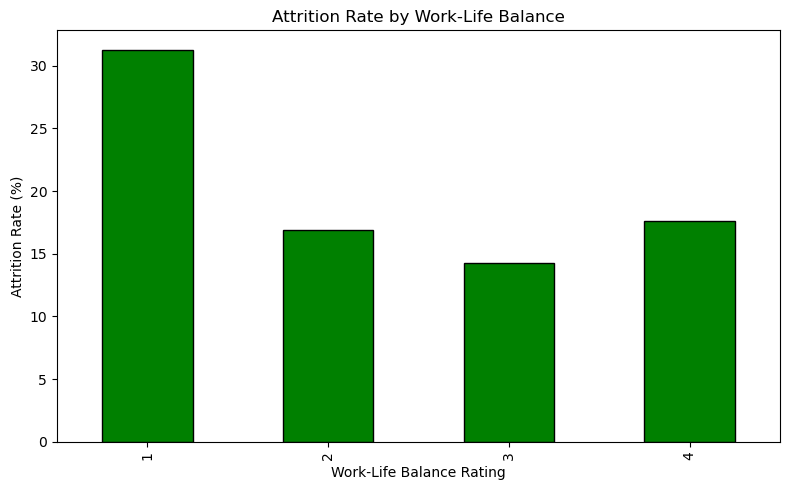

In [33]:
plt.figure(figsize=(8,5))

worklife_attrition.plot(
    kind="bar",
    color="green",
    edgecolor="black"
)

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig("charts/chart4_worklife_balance.png")

plt.show()

### Observation

- Employees with the lowest Work-Life Balance rating (1) have the highest attrition rate at approximately 31%.
- Attrition decreases significantly as the Work-Life Balance rating improves.
- Employees with ratings 2 and 3 have much lower attrition rates compared to those with rating 1.
- This indicates that maintaining a healthy work-life balance plays an important role in improving employee retention.

## Attrition vs Years at Company

In [34]:
# Create tenure groups
df["YearsGroup"] = pd.cut(
    df["YearsAtCompany"],
    bins=[0, 5, 10, 15, 20, 25, 40],
    labels=["0-5", "6-10", "11-15", "16-20", "21-25", "26-40"],
    include_lowest=True
)

In [35]:

years_attrition = df.groupby("YearsGroup", observed=False)["Attrition"].mean() * 100

years_attrition

YearsGroup
0-5      20.876289
6-10     12.276786
11-15     6.481481
16-20     6.944444
21-25     9.756098
26-40    16.000000
Name: Attrition, dtype: float64

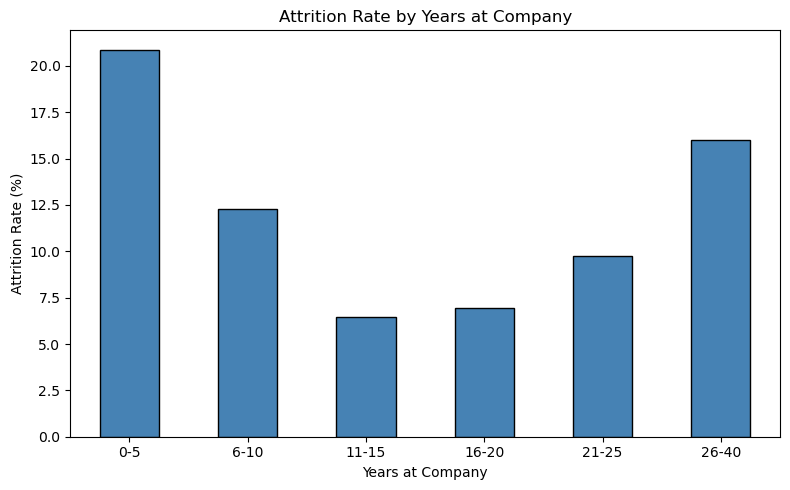

In [36]:
plt.figure(figsize=(8,5))

years_attrition.plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

plt.title("Attrition Rate by Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("charts/chart5_years_company.png")

plt.show()

### Observation

- Employees with 0–5 years of service have the highest attrition rate, at approximately 21%.
- Attrition decreases steadily for employees with 6–20 years of service, indicating better retention among experienced employees.
- A slight increase in attrition is observed for employees with more than 25 years of service, although this group contains fewer employees.
- The findings suggest that the company should focus on supporting employees during their early years, as this is when they are most likely to leave.

## Business Insights

1. The Sales department has the highest attrition rate (around 21%), making it the top priority for employee retention initiatives.

2. Sales Representatives experience the highest attrition rate (nearly 40%), indicating that this job role requires immediate attention from HR.

3. Employees with lower monthly incomes are more likely to leave the company, suggesting that compensation is an important factor in employee retention.

4. Employees reporting poor Work-Life Balance are significantly more likely to leave, highlighting the need for better work-life balance policies and employee well-being programs.

5. Most employee exits occur within the first five years of employment, suggesting that improving onboarding, mentoring, and career development during the early years could reduce attrition.

Sales department: "The Sales department has the highest attrition, so HR should investigate workload, incentives, and career growth opportunities in this department."

Sales Representatives: "This role has the highest turnover, indicating it may have higher stress or lower job satisfaction."

Monthly Income: "Lower-paid employees are more likely to leave, but since some high-income employees also leave, salary alone does not explain attrition."

Work-Life Balance: "Employees with poor work-life balance are much more likely to leave, so flexible work policies could improve retention."

Years at Company: "Most attrition happens in the first five years, so HR should focus on onboarding and supporting new employees."

## Model Building & Comparison

In [37]:
## spliting

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [38]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1176, 45)
Testing data: (294, 45)


In [39]:
## Logestic regression
log_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [40]:
## Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [41]:
#Gradient Boosting
gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [42]:
## predictions
log_pred = log_model.predict(X_test)

rf_pred = rf_model.predict(X_test)

gb_pred = gb_model.predict(X_test)

In [43]:
from sklearn.metrics import accuracy_score

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.755102
1,Random Forest,0.840136
2,Gradient Boosting,0.850340


## Model Evaluation

In [44]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)


## Evaluate Logistic Regression

In [45]:
print("Logistic Regression")
print(classification_report(y_test, log_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294



In [46]:
log_auc = roc_auc_score(
    y_test,
    log_model.predict_proba(X_test)[:,1]
)

print("ROC-AUC Score:", log_auc)

ROC-AUC Score: 0.8036006546644844


In [47]:
log_cm = confusion_matrix(y_test, log_pred)

print(log_cm)

[[191  56]
 [ 16  31]]


## Evaluate random forest

In [48]:
print("Random Forest")
print(classification_report(y_test, rf_pred))

Random Forest
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.50      0.06      0.11        47

    accuracy                           0.84       294
   macro avg       0.67      0.53      0.51       294
weighted avg       0.79      0.84      0.78       294



In [49]:
rf_auc = roc_auc_score(
    y_test,
    rf_model.predict_proba(X_test)[:,1]
)

print("ROC-AUC Score:", rf_auc)

ROC-AUC Score: 0.7752175036609527


In [50]:
rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[244   3]
 [ 44   3]]


## Evaluate Gradient Boosting

In [51]:
print("Gradient Boosting")
print(classification_report(y_test, gb_pred))

Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294



In [52]:
gb_auc = roc_auc_score(
    y_test,
    gb_model.predict_proba(X_test)[:,1]
)

print("ROC-AUC Score:", gb_auc)

ROC-AUC Score: 0.793694547333965


In [53]:
gb_cm = confusion_matrix(y_test, gb_pred)

print(gb_cm)

[[240   7]
 [ 37  10]]


## comparision table


In [54]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],

    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],

    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],

    "ROC-AUC": [
        log_auc,
        rf_auc,
        gb_auc
    ]
})

comparison

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.356322,0.659574,0.462687,0.803601
1,Random Forest,0.500000,0.063830,0.113208,0.775218
2,Gradient Boosting,0.588235,0.212766,0.312500,0.793695


## Best Model

Based on the evaluation metrics, Logistic Regression performed the best.

It achieved:
- Precision: 35.63%
- Recall: 65.96%
- F1-Score: 46.27%
- ROC-AUC Score: 80.36%

Since employee attrition prediction aims to identify as many employees who are likely to leave as possible, Recall is an important metric. Logistic Regression has the highest Recall, F1-Score, and ROC-AUC among the three models, making it the best model for this dataset.

In [55]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": abs(log_model.coef_[0])
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
44,OverTime_Yes,1.626169
24,BusinessTravel_Travel_Frequently,1.596964
35,JobRole_Laboratory Technician,1.571637
41,JobRole_Sales Representative,1.264294
38,JobRole_Research Director,1.112054
31,EducationField_Other,1.020279
25,BusinessTravel_Travel_Rarely,0.903722
43,MaritalStatus_Single,0.864502
34,JobRole_Human Resources,0.670991
17,TotalWorkingYears,0.612480


## Top 10 Important Features

The Logistic Regression model identified the following features as the most important factors influencing employee attrition:

1. OverTime_Yes
2. BusinessTravel_Travel_Frequently
3. JobRole_Laboratory Technician
4. JobRole_Sales Representative
5. JobRole_Research Director
6. EducationField_Other
7. BusinessTravel_Travel_Rarely
8. MaritalStatus_Single
9. JobRole_Human Resources
10. TotalWorkingYears

These features have the greatest influence on predicting whether an employee is likely to leave the company.

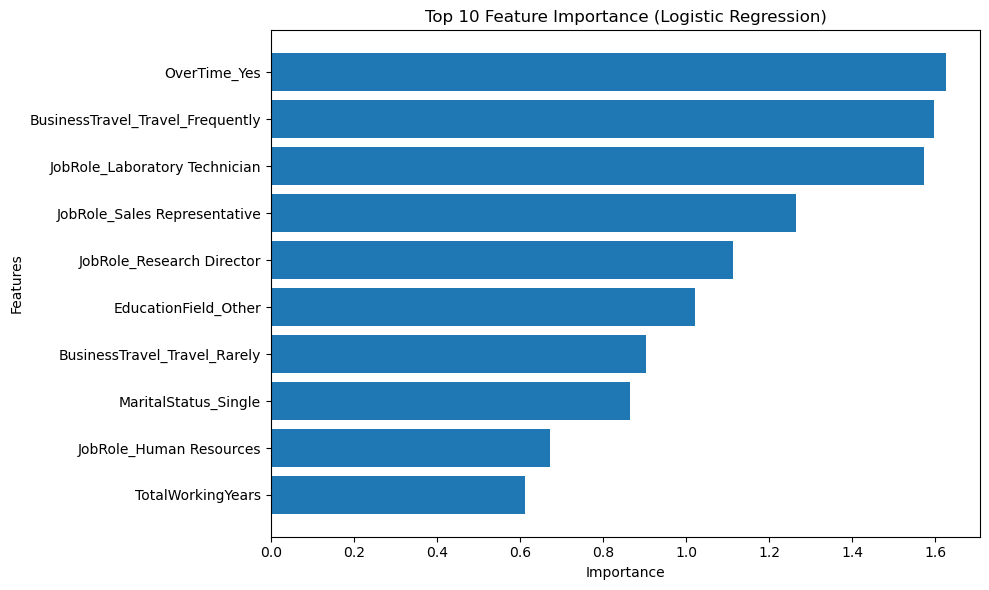

In [56]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10["Feature"], top10["Importance"])

plt.title("Top 10 Feature Importance (Logistic Regression)")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("charts/chart6_feature_importance.png")

plt.show()

In [57]:
import joblib

joblib.dump(log_model, "employee_attrition_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [58]:
joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


## Visualization

## Confusion Matrix Heatmap (Logistic regression Model)

In [59]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, log_pred)

cm

array([[191,  56],
       [ 16,  31]], dtype=int64)

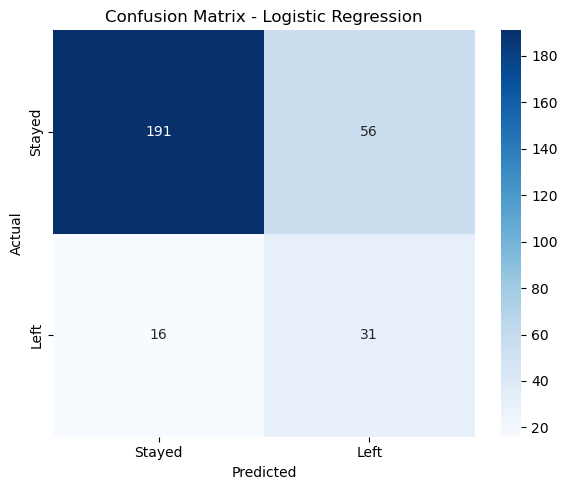

In [60]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig("charts/chart7_confusion_matrix.png")

plt.show()

### Observation

- The model correctly predicted **191 employees who stayed** (True Negatives).
- It correctly identified **31 employees who left** (True Positives).
- However, **56 employees who actually stayed were incorrectly predicted to leave** (False Positives).
- Only **16 employees who actually left were predicted to stay** (False Negatives).
- The model performs well at identifying employees who are likely to leave, which is important for HR since missing at-risk employees could lead to unexpected attrition.

## top 10 feature imortance

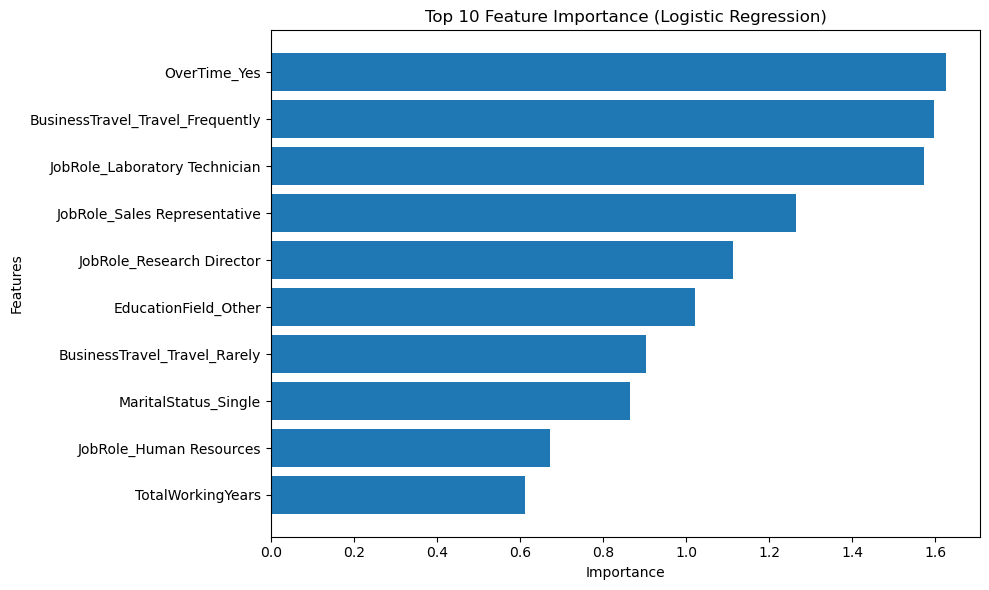

In [61]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10["Feature"], top10["Importance"])

plt.title("Top 10 Feature Importance (Logistic Regression)")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("charts/chart8_feature_importance.png")

plt.show()

## ROC Curve Comparison (Bonus)

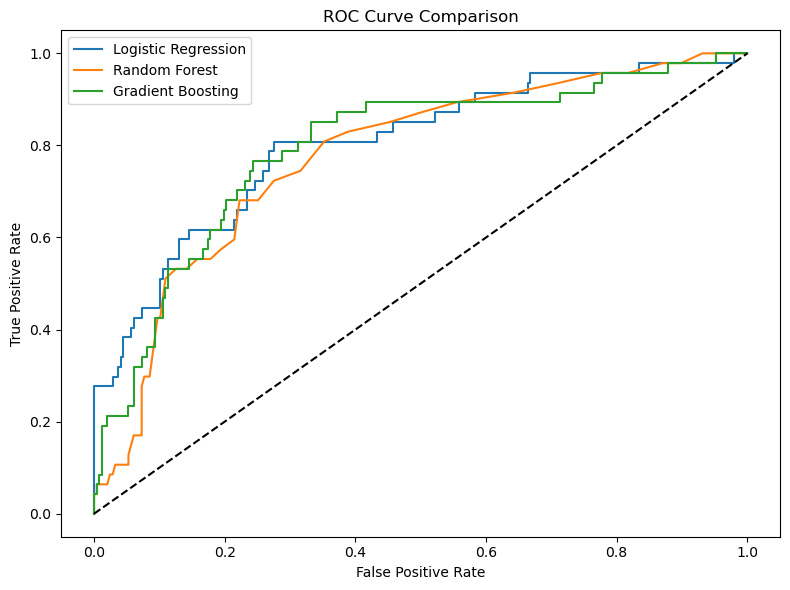

In [62]:
from sklearn.metrics import roc_curve

# Probability predictions
log_prob = log_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]
gb_prob = gb_model.predict_proba(X_test)[:, 1]

# ROC Curves
log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)

plt.figure(figsize=(8,6))

plt.plot(log_fpr, log_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot(gb_fpr, gb_tpr, label="Gradient Boosting")

plt.plot([0,1], [0,1], linestyle="--", color="black")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.tight_layout()

plt.savefig("charts/chart9_roc_curve.png")

plt.show()

### Observation

- The Logistic Regression model has the highest ROC-AUC score (0.804), indicating the best overall ability to distinguish between employees who stay and those who leave.
- Gradient Boosting achieved a ROC-AUC score of 0.794, performing slightly below Logistic Regression.
- Random Forest obtained the lowest ROC-AUC score of 0.775 among the three models.
- All three ROC curves lie above the diagonal reference line, indicating that each model performs better than random guessing.
- Based on the ROC-AUC values, Logistic Regression is the most effective model for predicting employee attrition in this dataset.

## HR Insights & Business Recommendations

### HR Insights

Based on the exploratory data analysis and the Logistic Regression model, the three strongest factors influencing employee attrition are **working overtime**, **frequent business travel**, and specific **job roles** such as Sales Representative and Laboratory Technician. The EDA also showed that the **Sales department** has the highest attrition rate, with Sales Representatives experiencing the greatest employee turnover. Therefore, HR should prioritize retention efforts for employees in the Sales department, particularly those who frequently travel and work overtime.

Although employees with lower monthly income tend to leave more often, **salary alone does not explain attrition**. Factors such as overtime, work-life balance, business travel, and job role have a stronger influence on whether an employee leaves the company.

### HR Recommendations

1. Introduce initiatives to reduce excessive overtime and improve work-life balance, especially for employees in the Sales department and other high-risk job roles. Regular workload reviews and flexible work arrangements may help improve employee retention.

2. Conduct periodic retention discussions with employees who frequently travel for work or are in their first few years with the company. Providing career development opportunities, mentoring programs, and recognition can help reduce voluntary attrition.

### Limitation of the Model

This model is trained on historical employee data and predicts attrition based only on the available features. It does not consider external factors such as personal circumstances, economic conditions, organizational changes, or employee motivations that are not included in the dataset. Therefore, the model should be used as a decision-support tool rather than the sole basis for HR decisions.
